# EEG Ratio Topomaps (A vs C)

This notebook performs a ratio-based EEG analysis for **Alzheimer's disease (A)** vs **Control (C)** only.

Ratios analyzed:
- **Theta/Alpha**
- **Theta/Beta**
- **Slow/Fast = (Theta + Alpha) / (Beta + Gamma)**

Channel-wise significance is tested with Welch's t-test and FDR correction (`q < 0.05`).
Only statistically significant electrodes are circled.

In [1]:
import os
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', str(Path.cwd() / '.mplconfig'))
os.environ.setdefault('XDG_CACHE_HOME', str(Path.cwd() / '.cache'))
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)
Path(os.environ['XDG_CACHE_HOME']).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from mne.stats import fdr_correction
from mne.channels.layout import _find_topomap_coords

mne.set_log_level('ERROR')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'savefig.dpi': 600,
    'savefig.bbox': 'tight',
})

In [2]:
# Configuration
DATA_ROOT = Path.cwd()
PARTICIPANTS_TSV = DATA_ROOT / 'participants.tsv'
GROUP_1 = 'A'  # Alzheimer's disease
GROUP_2 = 'C'  # Control
GROUP_LABELS = {'A': "Alzheimer's disease", 'C': 'Control'}

BANDS = {
    'theta': (4, 8),
    'alpha': (8, 13),
    'beta': (13, 30),
    'gamma': (30, 45),
}

PSD_FMIN = 4
PSD_FMAX = 45
N_FFT = 2048
FDR_ALPHA = 0.05
EPS = 1e-20

In [3]:
participants = pd.read_csv(PARTICIPANTS_TSV, sep='	')
participants = participants[['participant_id', 'Group']].dropna()
participants['set_path'] = participants['participant_id'].apply(
    lambda sid: DATA_ROOT / sid / 'eeg' / f'{sid}_task-eyesclosed_eeg.set'
)
participants = participants[participants['set_path'].apply(lambda p: p.exists())].reset_index(drop=True)
participants = participants[participants['Group'].isin([GROUP_1, GROUP_2])].copy()

n_a = int((participants['Group'] == GROUP_1).sum())
n_c = int((participants['Group'] == GROUP_2).sum())
print(f"Comparing {GROUP_LABELS[GROUP_1]} ({GROUP_1}, n={n_a}) vs {GROUP_LABELS[GROUP_2]} ({GROUP_2}, n={n_c})")
if n_a < 2 or n_c < 2:
    raise ValueError('Need at least 2 participants per group.')

Comparing Alzheimer's disease (A, n=36) vs Control (C, n=29)


In [4]:
def compute_subject_band_power(set_path, bands, fmin=4, fmax=45, n_fft=2048):
    raw = mne.io.read_raw_eeglab(set_path, preload=True, verbose='ERROR')
    raw.pick('eeg')
    raw.set_montage('standard_1020', on_missing='ignore')

    spectrum = raw.compute_psd(method='welch', fmin=fmin, fmax=fmax, n_fft=n_fft, verbose='ERROR')
    psd, freqs = spectrum.get_data(return_freqs=True)

    band_power = {}
    for name, (lo, hi) in bands.items():
        idx = (freqs >= lo) & (freqs < hi)
        band_power[name] = np.log10(psd[:, idx] + 1e-20).mean(axis=1)

    return raw.ch_names, raw.info, band_power

records = []
common_channels = None
first_info = None

for row in participants.itertuples(index=False):
    ch_names, info, band_power = compute_subject_band_power(row.set_path, BANDS, PSD_FMIN, PSD_FMAX, N_FFT)
    if first_info is None:
        first_info = info.copy()
    common_channels = set(ch_names) if common_channels is None else common_channels & set(ch_names)
    records.append({'id': row.participant_id, 'group': row.Group, 'ch_names': ch_names, 'band_power': band_power})

common_channels = [ch for ch in first_info['ch_names'] if ch in common_channels]
print(f'Common channels: {len(common_channels)}')
print(common_channels)

Common channels: 19
['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz']


In [5]:
# Build group-wise arrays for each band: (subjects x channels)
group_band_data = {band: {GROUP_1: [], GROUP_2: []} for band in BANDS}

for rec in records:
    idx = [rec['ch_names'].index(ch) for ch in common_channels]
    for band in BANDS:
        group_band_data[band][rec['group']].append(rec['band_power'][band][idx])

for band in BANDS:
    for grp in [GROUP_1, GROUP_2]:
        group_band_data[band][grp] = np.vstack(group_band_data[band][grp])

for band in BANDS:
    print(band, GROUP_1, group_band_data[band][GROUP_1].shape, GROUP_2, group_band_data[band][GROUP_2].shape)

theta A (36, 19) C (29, 19)
alpha A (36, 19) C (29, 19)
beta A (36, 19) C (29, 19)
gamma A (36, 19) C (29, 19)


In [6]:
# Ratio definitions in log-domain
ratio_defs = {
    'theta/alpha': lambda d, g: d['theta'][g] - d['alpha'][g],
    'theta/beta': lambda d, g: d['theta'][g] - d['beta'][g],
    'slow/fast': lambda d, g: np.log10(
        (10**d['theta'][g] + 10**d['alpha'][g] + EPS)
        /
        (10**d['beta'][g] + 10**d['gamma'][g] + EPS)
    ),
}

ratio_results = {}
for name, fn in ratio_defs.items():
    r1 = fn(group_band_data, GROUP_1)
    r2 = fn(group_band_data, GROUP_2)

    diff = r1.mean(axis=0) - r2.mean(axis=0)
    tvals, pvals = ttest_ind(r1, r2, axis=0, equal_var=False, nan_policy='omit')
    reject, pvals_fdr = fdr_correction(pvals, alpha=FDR_ALPHA, method='indep')

    # Cohen's d per channel
    var1 = r1.var(axis=0, ddof=1)
    var2 = r2.var(axis=0, ddof=1)
    n1 = r1.shape[0]
    n2 = r2.shape[0]
    pooled = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (max(n1 + n2 - 2, 1)))
    d = (r1.mean(axis=0) - r2.mean(axis=0)) / (pooled + 1e-20)

    ratio_results[name] = {
        'diff': diff,
        'tvals': tvals,
        'pvals': pvals,
        'pvals_fdr': pvals_fdr,
        'reject': reject,
        'cohens_d': d,
        'marked_channels': [common_channels[i] for i in np.where(reject)[0]],
    }

summary_df = pd.DataFrame([
    {
        'ratio': name,
        'num_fdr_sig': int(out['reject'].sum()),
        'min_p': float(np.min(out['pvals'])),
        'min_q': float(np.min(out['pvals_fdr'])),
        'fdr_channels': ', '.join(out['marked_channels']) if out['marked_channels'] else 'None',
    }
    for name, out in ratio_results.items()
])
summary_df

,ratio,num_fdr_sig,min_p,min_q,fdr_channels
0,theta/alpha,16,4.846883e-07,0.000009,"Fp1, Fp2, F3, F4, P3, P4, O1, O2, F7, F8, T3, ..."
1,theta/beta,1,1.063362e-03,0.020204,O2
2,slow/fast,0,3.184128e-01,0.968602,None


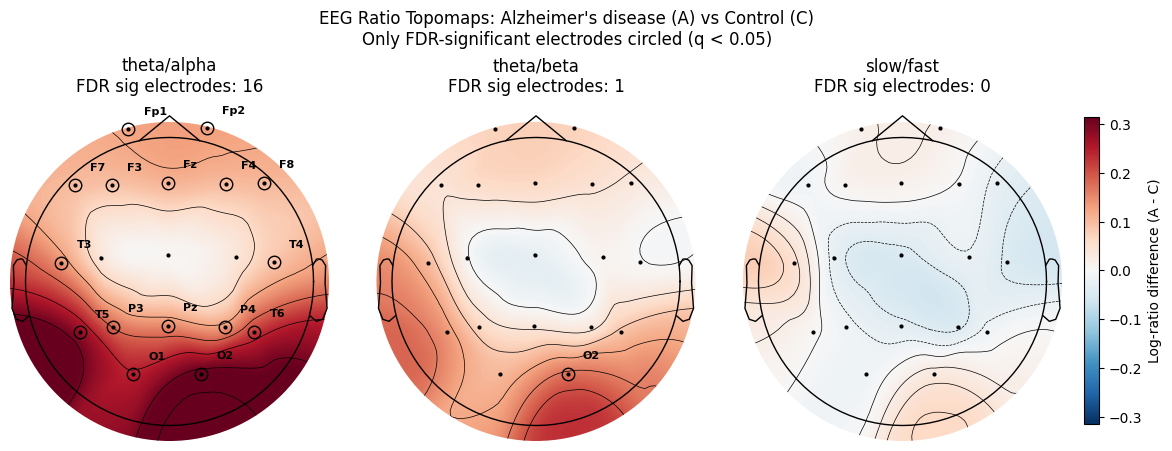

Saved topomap_ratio_publication_ready.png


In [7]:
# Publication-ready ratio topomaps
info_plot = mne.create_info(ch_names=common_channels, sfreq=first_info['sfreq'], ch_types='eeg')
info_plot.set_montage('standard_1020', on_missing='ignore')
xy = _find_topomap_coords(info_plot, picks=np.arange(len(common_channels)))

global_lim = max(np.max(np.abs(out['diff'])) for out in ratio_results.values())
global_lim = max(global_lim, 1e-6)

fig, axes = plt.subplots(1, 3, figsize=(12, 4.4), constrained_layout=True)
for ax, name in zip(axes, ratio_results.keys()):
    out = ratio_results[name]
    mask = out['reject']

    im, _ = mne.viz.plot_topomap(
        out['diff'],
        info_plot,
        axes=ax,
        cmap='RdBu_r',
        vlim=(-global_lim, global_lim),
        contours=6,
        show=False,
        mask=mask,
        mask_params={
            'marker': 'o',
            'linestyle': 'None',
            'markerfacecolor': 'none',
            'markeredgecolor': 'black',
            'linewidth': 1.6,
            'markersize': 9,
        },
    )

    # Always show sensor dots
    ax.scatter(xy[:, 0], xy[:, 1], s=9, c='black', linewidths=0, zorder=6)

    # Label only FDR-significant channels
    for idx in np.where(mask)[0]:
        x, y = xy[idx]
        ax.text(x + 0.01, y + 0.01, common_channels[idx], fontsize=8, weight='bold', color='black', zorder=8)

    sig_n = int(mask.sum())
    ax.set_title(f"{name}\nFDR sig electrodes: {sig_n}")

cbar = fig.colorbar(im, ax=axes, shrink=0.9, pad=0.02)
cbar.set_label('Log-ratio difference (A - C)')
fig.suptitle(
    "EEG Ratio Topomaps: Alzheimer's disease (A) vs Control (C)\n"
    f"Only FDR-significant electrodes circled (q < {FDR_ALPHA})",
    fontsize=12,
)

fig.savefig('topomap_ratio_publication_ready.png', dpi=600, bbox_inches='tight')
plt.show()
print('Saved topomap_ratio_publication_ready.png')

In [8]:
# Detailed per-channel statistics for each ratio
for name, out in ratio_results.items():
    df_ratio = pd.DataFrame({
        'channel': common_channels,
        'diff_mean_log_ratio': out['diff'],
        'cohens_d': out['cohens_d'],
        'p_value': out['pvals'],
        'q_value_fdr': out['pvals_fdr'],
        'fdr_significant': out['reject'],
    }).sort_values('q_value_fdr', ascending=True)

    print(f"\n=== {name} ===")
    display(df_ratio.head(10))


=== theta/alpha ===


,channel,diff_mean_log_ratio,cohens_d,p_value,q_value_fdr,fdr_significant
9,O2,0.314907,1.420474,4.846883e-07,0.000009,True
14,T5,0.272000,1.224146,1.115396e-05,0.000106,True
15,T6,0.217083,1.010809,1.394049e-04,0.000662,True
8,O1,0.243839,1.053841,1.077394e-04,0.000662,True
6,P3,0.177877,0.901135,6.433087e-04,0.002445,True
12,T3,0.137337,0.750384,2.919614e-03,0.009245,True
18,Pz,0.146875,0.759189,3.946226e-03,0.010711,True
1,Fp2,0.128086,0.711430,5.177455e-03,0.012296,True
0,Fp1,0.123557,0.667057,8.467942e-03,0.017877,True
7,P4,0.132309,0.653873,1.110503e-02,0.021100,True



=== theta/beta ===


,channel,diff_mean_log_ratio,cohens_d,p_value,q_value_fdr,fdr_significant
9,O2,0.166399,0.830103,0.001063,0.020204,True
14,T5,0.134123,0.598928,0.016008,0.152077,False
12,T3,0.097516,0.420902,0.075404,0.358171,False
8,O1,0.101813,0.470447,0.063036,0.358171,False
15,T6,0.087155,0.400264,0.102396,0.389105,False
6,P3,0.064139,0.314593,0.203146,0.482472,False
0,Fp1,0.071216,0.313753,0.202253,0.482472,False
1,Fp2,0.070795,0.318300,0.190938,0.482472,False
16,Fz,0.061808,0.288532,0.228672,0.482751,False
2,F3,0.056928,0.261309,0.268811,0.510742,False



=== slow/fast ===


,channel,diff_mean_log_ratio,cohens_d,p_value,q_value_fdr,fdr_significant
0,Fp1,0.016810,0.079728,0.745630,0.968602,False
16,Fz,0.013387,0.069965,0.768759,0.968602,False
15,T6,-0.013698,-0.067678,0.779092,0.968602,False
14,T5,0.004321,0.020681,0.930752,0.968602,False
13,T4,-0.043058,-0.169961,0.477447,0.968602,False
12,T3,0.045780,0.189588,0.419315,0.968602,False
11,F8,-0.025565,-0.109032,0.647750,0.968602,False
10,F7,-0.008788,-0.031180,0.894823,0.968602,False
17,Cz,-0.045660,-0.244545,0.318420,0.968602,False
9,O2,0.028333,0.136835,0.581106,0.968602,False


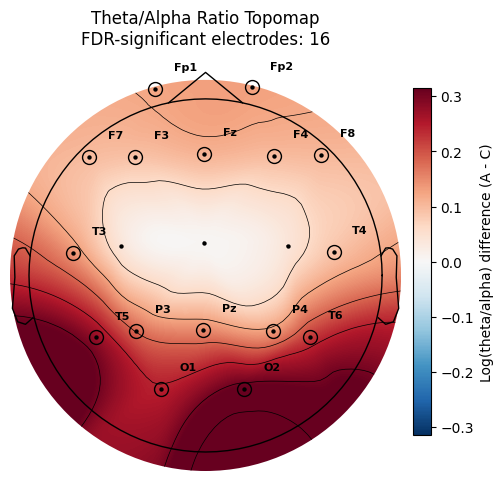

Saved poster_theta_alpha_only.png


In [9]:
# theta/alpha-only poster export (from notebook results)
name = 'theta/alpha'
out = ratio_results[name]

fig, ax = plt.subplots(figsize=(5.1, 4.7), constrained_layout=True)
lim = max(np.max(np.abs(out['diff'])), 1e-6)
im, _ = mne.viz.plot_topomap(
    out['diff'],
    info_plot,
    axes=ax,
    cmap='RdBu_r',
    vlim=(-lim, lim),
    contours=6,
    show=False,
    mask=out['reject'],
    mask_params={
        'marker': 'o',
        'linestyle': 'None',
        'markerfacecolor': 'none',
        'markeredgecolor': 'black',
        'linewidth': 1.8,
        'markersize': 10,
    },
)

ax.scatter(xy[:, 0], xy[:, 1], s=10, c='black', linewidths=0, zorder=6)
for idx in np.where(out['reject'])[0]:
    x, y = xy[idx]
    ax.text(x + 0.01, y + 0.01, common_channels[idx], fontsize=8, weight='bold', zorder=8)

cbar = fig.colorbar(im, ax=ax, shrink=0.83, pad=0.03)
cbar.set_label('Log(theta/alpha) difference (A - C)')
ax.set_title(f"Theta/Alpha Ratio Topomap\nFDR-significant electrodes: {int(out['reject'].sum())}")
fig.savefig('poster_theta_alpha_only.png', dpi=600, bbox_inches='tight')
plt.show()
print('Saved poster_theta_alpha_only.png')